In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import rdkit
import sys
import seaborn as sns
from rdkit import rdBase, Chem, DataStructs
from rdkit.Chem import AllChem, PandasTools
import pubchempy as pcp
from rdkit.Chem.Fraggle import FraggleSim

In [11]:
a_glu_df = pd.read_csv("../datasets/231113_a-glucosidase_dataset_all.csv", encoding='shift jis')
kampo_df = pd.read_csv("../ESI_3/virtual_screening_result/kampo_virtual_screening_ESI-3_top100_pIC50.csv", encoding='shift jis')

PandasTools.AddMoleculeColumnToFrame(a_glu_df,'Smiles','molecule',includeFingerprints=True)
PandasTools.AddMoleculeColumnToFrame(kampo_df,'smiles','molecule',includeFingerprints=True)# dfのmoleculeという列にMolオブジェクトを追加する。

a_glu_df

,comp_name,ChEMBL ID,Smiles,IC50(nM),IC50(M),pIC50,rUV,rex,rorb,rIR,...,1/dE22,1/dE23,1/dE24,1/dE25,1/dE26,1/dE27,1/dE28,1/dE29,1/dE30,molecule
0,comp_001,CHEMBL4576254,C=C(C)C(COc1c2ccoc2cc2oc(=O)ccc12)OC(C)(C)C(O)...,8800,0.0000,5.0555,35.3738,27.3813,92.3769,58.5249,...,0.1511,0.1499,0.1482,0.1478,0.1472,0.1471,0.1467,0.1459,0.1455,<rdkit.Chem.rdchem.Mol object at 0x7fe7e8786650>
1,comp_002,CHEMBL4516633,O=C(Cn1nnc2ccccc21)c1cccc(Cl)c1Cl,3470,0.0000,5.4597,9.4888,27.5001,90.2487,37.0927,...,0.1410,0.1378,0.1355,0.1346,0.1345,0.1338,0.1334,0.1324,0.1317,<rdkit.Chem.rdchem.Mol object at 0x7fe812a84740>
2,comp_004,CHEMBL4453302,Cc1cccc2nc(-c3ccccc3Cl)[nH]c12,5300,0.0000,5.2757,14.2948,11.8939,89.8817,32.3868,...,0.1274,0.1257,0.1254,0.1232,0.1229,0.1227,0.1220,0.1218,0.1214,<rdkit.Chem.rdchem.Mol object at 0x7fe812a84820>
3,comp_005,CHEMBL4593597,O=C1NC(=O)/C(=C/c2ccc(-c3nc4ccccc4n3Cc3ccc(Cl)...,540,0.0000,6.2676,33.2624,39.0094,92.1613,53.8145,...,0.1577,0.1570,0.1562,0.1537,0.1532,0.1517,0.1509,0.1499,0.1490,<rdkit.Chem.rdchem.Mol object at 0x7fe812a84900>
4,comp_006,CHEMBL4460212,Clc1ccc(CSc2nc(-c3ccc(Br)cc3)cc(-c3ccc(Br)cc3)...,19000,0.0000,4.7212,52.1525,33.3409,87.6914,24.4834,...,0.1563,0.1559,0.1557,0.1552,0.1528,0.1525,0.1519,0.1511,0.1504,<rdkit.Chem.rdchem.Mol object at 0x7fe812a849e0>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428,comp_568,CHEMBL3900431,O=C(Cn1cc(Cn2c(-c3ccc(F)cc3)nc(-c3ccccc3)c2-c2...,15000,0.0000,4.8239,41.0578,30.2186,94.2726,28.9944,...,0.1548,0.1542,0.1536,0.1530,0.1526,0.1509,0.1493,0.1493,0.1483,<rdkit.Chem.rdchem.Mol object at 0x7fe812e5b8b0>
429,comp_569,CHEMBL4458760,Cc1ccc(-c2cc(-c3cccc(Br)c3)nc(SCc3ccc(F)cc3)n2...,19000,0.0000,4.7212,47.8936,33.4961,91.6509,36.3355,...,0.1546,0.1543,0.1540,0.1526,0.1521,0.1512,0.1496,0.1481,0.1459,<rdkit.Chem.rdchem.Mol object at 0x7fe812e5b990>
430,comp_570,CHEMBL4568608,Cc1ccc(-c2cc(-c3cccc(Br)c3)nc(SCc3cccc(F)c3)n2...,19000,0.0000,4.7212,47.7727,33.5077,92.3585,28.4074,...,0.1574,0.1540,0.1529,0.1527,0.1513,0.1504,0.1482,0.1463,0.1456,<rdkit.Chem.rdchem.Mol object at 0x7fe812e5ba70>
431,comp_572,CHEMBL4550622,Nc1nnc(-c2ccc([N+](=O)[O-])cc2)s1,2300,0.0000,5.6383,15.8358,23.6077,82.7969,32.8829,...,0.1345,0.1337,0.1323,0.1307,0.1295,0.1293,0.1271,0.1268,0.1265,<rdkit.Chem.rdchem.Mol object at 0x7fe812e5bb50>


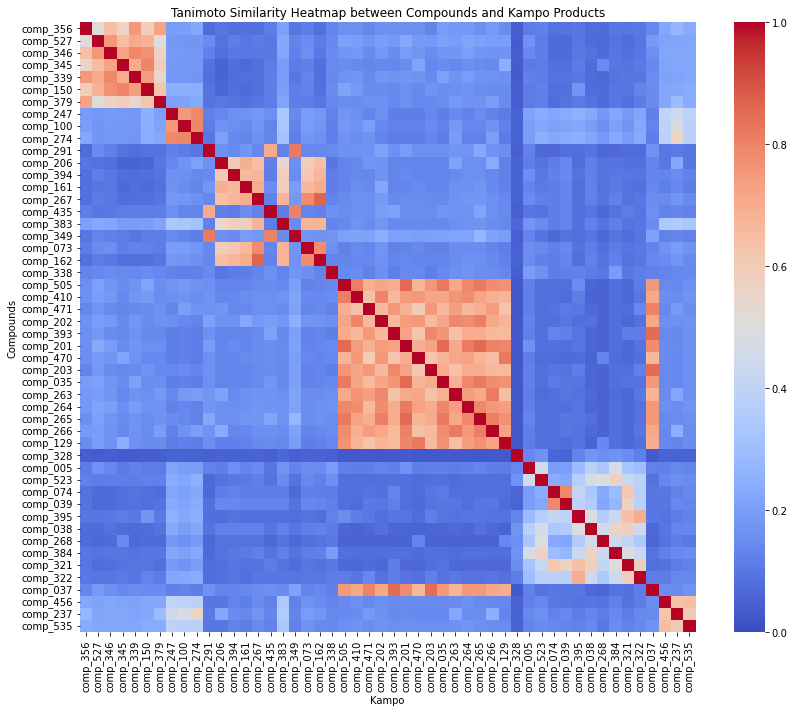

In [25]:
a_glu_df = pd.read_csv("../datasets/231113_a-glucosidase_dataset_all.csv", encoding='shift jis')
a_glu_df.sort_values('pIC50', ascending=False, inplace=True)
a_glu_df = a_glu_df.iloc[:50]
PandasTools.AddMoleculeColumnToFrame(a_glu_df,'Smiles','molecule',includeFingerprints=True)

# Tanimoto coefficientを計算する。
a_glu_mol = a_glu_df.iloc[:,-1]# Molオブジェクトのpd.Series
tanimotos = []

a_glu_morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(a_glu, 2, 2048) for a_glu in a_glu_mol]

for i in range(a_glu_df.shape[0]):
    tanimoto = DataStructs.BulkTanimotoSimilarity(a_glu_morgan_fp [i], a_glu_morgan_fp)
    #print(tanimoto)
    tanimotos.append(tanimoto)

df_sim = pd.DataFrame(tanimotos, index=a_glu_df['comp_name'], columns=a_glu_df['comp_name'])
pd.options.display.float_format = '{:.4f}'.format # 小数点を3桁に設定する。

df_sim.to_csv(f"tanimoto_similarity_inter_a_glu.csv")
#print(df_sim)

plt.figure(figsize=(12, 10))

# Creating the heatmap
sns.heatmap(df_sim, cmap="coolwarm",vmax=1.0 ,vmin=0.0)
plt.title('Tanimoto Similarity Heatmap between Compounds and Kampo Products')
plt.xlabel('Kampo')
plt.ylabel('Compounds')

# Displaying the heatmap
plt.tight_layout() # Adjusts plot to ensure everything fits without overlap
plt.show()

In [26]:
df_sim

comp_name,comp_356,comp_527,comp_346,comp_345,comp_339,comp_150,comp_379,comp_247,comp_100,comp_274,...,comp_395,comp_038,comp_268,comp_384,comp_321,comp_322,comp_037,comp_456,comp_237,comp_535
comp_name,,,,,,,,,,,,,,,,,,,,,
comp_356,1.0000,0.5119,0.6400,0.5625,0.7500,0.5921,0.7286,0.1942,0.2019,0.2233,...,0.0971,0.0769,0.0737,0.0989,0.0947,0.1019,0.1383,0.2289,0.2771,0.2381
comp_527,0.5119,1.0000,0.7568,0.6500,0.7051,0.6842,0.5059,0.1818,0.1786,0.1770,...,0.1009,0.0714,0.0686,0.0918,0.0777,0.0957,0.1875,0.2111,0.2151,0.2198
comp_346,0.6400,0.7568,1.0000,0.7297,0.7917,0.7714,0.5696,0.1887,0.1852,0.1835,...,0.1048,0.0860,0.0714,0.0957,0.0808,0.0991,0.1579,0.2209,0.2247,0.2299
comp_345,0.5625,0.6500,0.7297,1.0000,0.7013,0.8000,0.5949,0.1852,0.1818,0.1802,...,0.1132,0.0729,0.1505,0.0938,0.0900,0.1071,0.1429,0.2159,0.2198,0.2247
comp_339,0.7500,0.7051,0.7917,0.7013,1.0000,0.7397,0.5488,0.1835,0.1802,0.1786,...,0.1019,0.0722,0.0693,0.0928,0.1000,0.0965,0.1531,0.2135,0.2174,0.2222
comp_150,0.5921,0.6842,0.7714,0.8000,0.7397,1.0000,0.6267,0.2525,0.2475,0.2451,...,0.1753,0.0761,0.0729,0.0978,0.0938,0.1321,0.1489,0.2262,0.2299,0.2353
comp_379,0.7286,0.5059,0.5696,0.5949,0.5488,0.6267,1.0000,0.2039,0.2115,0.2330,...,0.1068,0.0879,0.0729,0.0978,0.0825,0.1111,0.1489,0.2262,0.2892,0.2353
comp_247,0.1942,0.1818,0.1887,0.1852,0.1835,0.2525,0.2039,1.0000,0.7534,0.7917,...,0.2609,0.2317,0.1798,0.2262,0.1889,0.2200,0.1224,0.4000,0.4342,0.3896
comp_100,0.2019,0.1786,0.1852,0.1818,0.1802,0.2475,0.2115,0.7534,1.0000,0.7945,...,0.2292,0.1977,0.1630,0.2069,0.1720,0.2277,0.1313,0.3896,0.4800,0.3797


In [24]:
a_glu_df

,comp_name,ChEMBL ID,Smiles,IC50(nM),IC50(M),pIC50,rUV,rex,rorb,rIR,...,1/dE22,1/dE23,1/dE24,1/dE25,1/dE26,1/dE27,1/dE28,1/dE29,1/dE30,molecule
265,comp_356,CHEMBL4448264,O=c1oc2ccccc2cc1-c1nn(C(Nc2ccc(Oc3ccc(NC(c4ccc...,70,0.0000,7.1549,93.4299,87.0453,96.0981,72.2812,...,0.1950,0.1945,0.1944,0.1940,0.1929,0.1890,0.1876,0.1861,0.1859,<rdkit.Chem.rdchem.Mol object at 0x7fe8023f4660>
395,comp_527,CHEMBL4448033,O=c1cc(-c2nn(C(Nc3ccc(-c4ccc(NC(c5ccc(Cl)cc5Cl...,70,0.0000,7.1549,80.5714,93.4816,96.7423,76.5921,...,0.1943,0.1931,0.1919,0.1904,0.1899,0.1892,0.1882,0.1867,0.1865,<rdkit.Chem.rdchem.Mol object at 0x7fe8023f4740>
259,comp_346,CHEMBL4535608,O=c1cc(-c2nn(C(Nc3ccc(NC(c4cccc(Cl)c4)n4nc(-c5...,70,0.0000,7.1549,97.4103,93.7941,97.5858,87.9571,...,0.1916,0.1906,0.1900,0.1894,0.1867,0.1851,0.1840,0.1839,0.1832,<rdkit.Chem.rdchem.Mol object at 0x7fe8023f4820>
258,comp_345,CHEMBL4551617,O=c1cc(-c2nn(C(Nc3ccc(NC(c4ccc([N+](=O)[O-])cc...,70,0.0000,7.1549,94.7632,74.2081,95.7519,87.6904,...,0.2056,0.2042,0.1959,0.1956,0.1951,0.1946,0.1923,0.1899,0.1894,<rdkit.Chem.rdchem.Mol object at 0x7fe8023f4900>
252,comp_339,CHEMBL4466971,O=c1cc(-c2nn(C(Nc3ccc(-c4ccc(NC(c5cccc(Br)c5)n...,70,0.0000,7.1549,81.7394,87.7939,96.9581,76.4296,...,0.1953,0.1944,0.1935,0.1922,0.1894,0.1866,0.1860,0.1856,0.1852,<rdkit.Chem.rdchem.Mol object at 0x7fe8023f49e0>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,comp_572,CHEMBL4550622,Nc1nnc(-c2ccc([N+](=O)[O-])cc2)s1,2300,0.0000,5.6383,15.8358,23.6077,82.7969,32.8829,...,0.1345,0.1337,0.1323,0.1307,0.1295,0.1293,0.1271,0.1268,0.1265,<rdkit.Chem.rdchem.Mol object at 0x7fe8023c1a10>
63,comp_094,CHEMBL4442388,COc1ccc(Br)cc1/C=N/c1nnc(-c2cccc([N+](=O)[O-])...,2300,0.0000,5.6383,57.1138,33.1679,89.2498,31.8334,...,0.1596,0.1561,0.1537,0.1527,0.1525,0.1513,0.1495,0.1483,0.1472,<rdkit.Chem.rdchem.Mol object at 0x7fe8023c1af0>
243,comp_324,CHEMBL4471901,O=[N+]([O-])c1ccccc1/C=N/c1nnc(-c2ccc(Cl)cc2)s1,2300,0.0000,5.6383,59.4513,36.6285,89.2895,15.2155,...,0.1540,0.1524,0.1513,0.1503,0.1485,0.1482,0.1469,0.1460,0.1453,<rdkit.Chem.rdchem.Mol object at 0x7fe8023c1bd0>
242,comp_323,CHEMBL4466501,Nc1nnc(-c2c3ccccc3cc3ccccc23)s1,2300,0.0000,5.6383,34.3543,30.4024,88.7024,24.5505,...,0.1512,0.1504,0.1482,0.1433,0.1430,0.1425,0.1416,0.1406,0.1395,<rdkit.Chem.rdchem.Mol object at 0x7fe8023c1cb0>


In [6]:
# Tanimoto coefficientを計算する。
kampo_mol = kampo_df.iloc[:,-1]# Molオブジェクトのpd.Series
tanimotos = []

kampo_morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(kmol, 2, 2048) for kmol in kampo_mol]

for i in range(kampo_df.shape[0]):
    tanimoto = DataStructs.BulkTanimotoSimilarity(kampo_morgan_fp[i], kampo_morgan_fp)
    #print(tanimoto)
    tanimotos.append(tanimoto)

df_sim = pd.DataFrame(tanimotos, index=kampo_df['number'], columns=kampo_df['number'])
pd.options.display.float_format = '{:.4f}'.format # 小数点を3桁に設定する。

df_sim.to_csv(f"tanimoto_similarity_kampo_by_ESI-3.csv")
df_sim

number,kampo_0400,kampo_1015,kampo_2591,kampo_1963,kampo_0547,kampo_2332,kampo_1179,kampo_0759,kampo_1123,kampo_2437,...,kampo_2838,kampo_0051,kampo_1445,kampo_1984,kampo_0441,kampo_2777,kampo_1778,kampo_2404,kampo_2492,kampo_0772
number,,,,,,,,,,,,,,,,,,,,,
kampo_0400,1.0000,0.1641,0.1368,0.2982,0.1125,0.1604,0.1429,0.1364,0.1242,0.1880,...,0.1250,0.0816,0.1304,0.1151,0.0741,0.1376,0.1224,0.1856,0.1000,0.0702
kampo_1015,0.1641,1.0000,0.1402,0.1709,0.0844,0.1313,0.3929,0.2128,0.1184,0.3763,...,0.1279,0.0556,0.1071,0.0827,0.0714,0.1771,0.1000,0.2093,0.0732,0.0777
kampo_2591,0.1368,0.1402,1.0000,0.1415,0.1269,0.3521,0.2169,0.1807,0.1407,0.1667,...,0.1408,0.0676,0.1846,0.1532,0.1125,0.1279,0.1690,0.2055,0.1250,0.0920
kampo_1963,0.2982,0.1709,0.1415,1.0000,0.1067,0.1212,0.1485,0.1531,0.1342,0.1651,...,0.1163,0.0682,0.1358,0.0916,0.0833,0.1200,0.1264,0.1319,0.1013,0.0891
kampo_0547,0.1125,0.0844,0.1269,0.1067,1.0000,0.0846,0.1061,0.0833,0.8952,0.0903,...,0.0678,0.1273,0.0796,0.1019,0.0635,0.0840,0.1327,0.0726,0.1359,0.0526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
kampo_2777,0.1376,0.1771,0.1279,0.1200,0.0840,0.1600,0.1500,0.1867,0.0821,0.1839,...,0.1613,0.1111,0.1525,0.0917,0.1268,1.0000,0.1212,0.2154,0.1053,0.1026
kampo_1778,0.1224,0.1000,0.1690,0.1264,0.1327,0.1406,0.1304,0.1364,0.1696,0.1410,...,0.1600,0.1915,0.2273,0.1053,0.2222,0.1212,1.0000,0.1607,0.2895,0.2000
kampo_2404,0.1856,0.2093,0.2055,0.1319,0.0726,0.2581,0.2029,0.2121,0.0794,0.2703,...,0.1887,0.1091,0.1346,0.1000,0.1094,0.2154,0.1607,1.0000,0.1739,0.1000


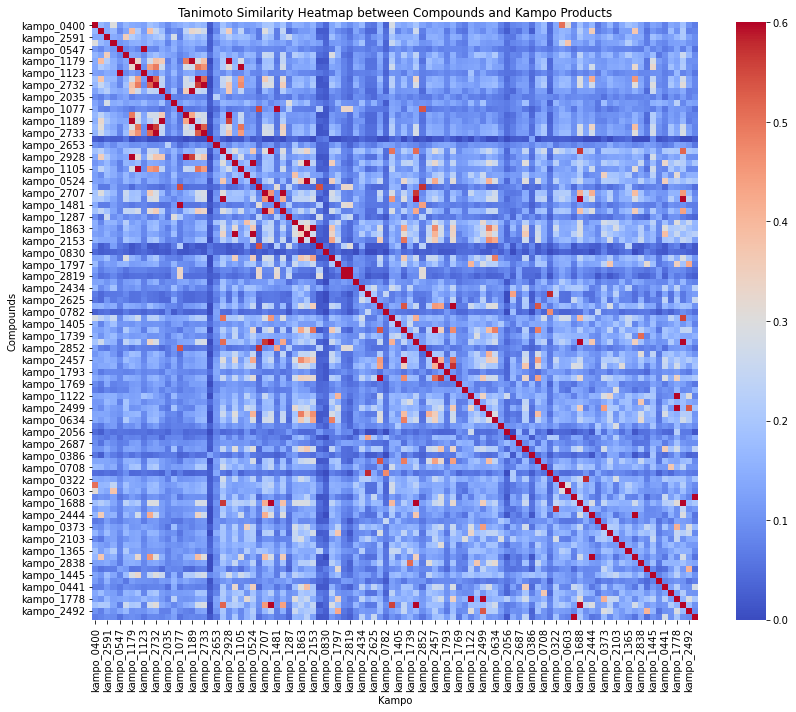

In [7]:
plt.figure(figsize=(12, 10))

# Creating the heatmap
#sns.heatmap(df_sim, cmap="YlGnBu")
sns.heatmap(df_sim, cmap="coolwarm",vmax=0.6, vmin=0.0)
plt.title('Tanimoto Similarity Heatmap between Compounds and Kampo Products')
plt.xlabel('Kampo')
plt.ylabel('Compounds')

# Displaying the heatmap
plt.tight_layout() # Adjusts plot to ensure everything fits without overlap
plt.show()

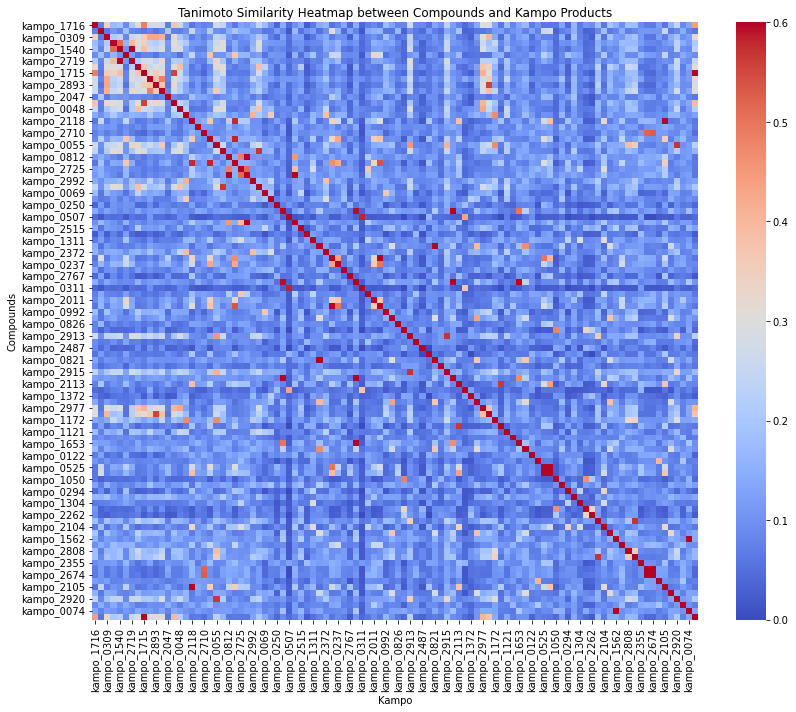

In [8]:
kampo_df = pd.read_csv("../summury/kampo_virtual_screening_ECFP4_top100_pIC50.csv", encoding='shift jis')
PandasTools.AddMoleculeColumnToFrame(kampo_df,'smiles','molecule',includeFingerprints=True)# dfのmoleculeという列にMolオブジェクトを追加する。

# Tanimoto coefficientを計算する。
kampo_mol = kampo_df.iloc[:,-1]# Molオブジェクトのpd.Series
tanimotos = []

kampo_morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(kmol, 2, 2048) for kmol in kampo_mol]

for i in range(kampo_df.shape[0]):
    tanimoto = DataStructs.BulkTanimotoSimilarity(kampo_morgan_fp[i], kampo_morgan_fp)
    #print(tanimoto)
    tanimotos.append(tanimoto)

df_sim = pd.DataFrame(tanimotos, index=kampo_df['number'], columns=kampo_df['number'])
pd.options.display.float_format = '{:.4f}'.format # 小数点を3桁に設定する。

df_sim.to_csv(f"tanimoto_similarity_kampo_by_ECFP4.csv")
#print(df_sim)

plt.figure(figsize=(12, 10))

# Creating the heatmap
sns.heatmap(df_sim,cmap="coolwarm",vmax=0.6 ,vmin=0.0)
plt.title('Tanimoto Similarity Heatmap between Compounds and Kampo Products')
plt.xlabel('Kampo')
plt.ylabel('Compounds')

# Displaying the heatmap
plt.tight_layout() # Adjusts plot to ensure everything fits without overlap
plt.show()

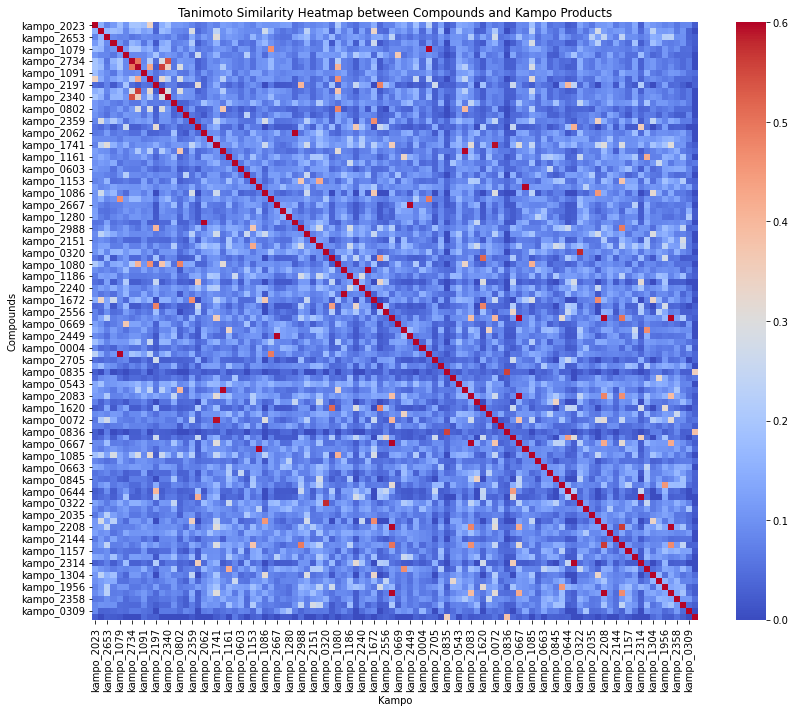

In [9]:
kampo_df = pd.read_csv("../summury/kampo_virtual_screening_rdkit_top100_pIC50.csv", encoding='shift jis')
PandasTools.AddMoleculeColumnToFrame(kampo_df,'smiles','molecule',includeFingerprints=True)# dfのmoleculeという列にMolオブジェクトを追加する。

# Tanimoto coefficientを計算する。
kampo_mol = kampo_df.iloc[:,-1]# Molオブジェクトのpd.Series
tanimotos = []

kampo_morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(kmol, 2, 2048) for kmol in kampo_mol]

for i in range(kampo_df.shape[0]):
    tanimoto = DataStructs.BulkTanimotoSimilarity(kampo_morgan_fp [i], kampo_morgan_fp)
    #print(tanimoto)
    tanimotos.append(tanimoto)

df_sim = pd.DataFrame(tanimotos, index=kampo_df['number'], columns=kampo_df['number'])
pd.options.display.float_format = '{:.4f}'.format # 小数点を3桁に設定する。

df_sim.to_csv(f"tanimoto_similarity_kampo_by_rdkit.csv")
#print(df_sim)

plt.figure(figsize=(12, 10))

# Creating the heatmap
sns.heatmap(df_sim, cmap="coolwarm",vmax=0.6 ,vmin=0.0)
plt.title('Tanimoto Similarity Heatmap between Compounds and Kampo Products')
plt.xlabel('Kampo')
plt.ylabel('Compounds')

# Displaying the heatmap
plt.tight_layout() # Adjusts plot to ensure everything fits without overlap
plt.show()